In [1]:
import math
import numpy as np
from SDP_utils.combinatorics import occupation_index, nu_set_iterator, multinomial, nu_iterator, dim_sym_kd
from SDP_utils.isotopic_proj import isotypic_projector
from tqdm.notebook import tqdm
import numpy as np
import picos
from SDP_utils.E_t import E_t_lower_lambda_r2
from toqito.state_props import is_separable

SDP_TOL = 10 ** (-7)

In [2]:
from SDP_utils.sdp import SDP

In [3]:
import os
import json
import numpy as np
from tqdm.notebook import tqdm
from SDP_utils.sdp import SDP, SDP_max
from SDP_utils.E_t import E_t_upperk2r2
from toqito.state_props import is_separable

SDP_TOL = 10 ** (-7)
RESULTS_DIR = "sdp_results"

# Parameter values are used as dictionary keys to decide whether a point has
# already been computed, so they are rounded first: np.arange happily produces
# 0.15000000000000002 instead of 0.15, and two sweeps built with different
# steps must still agree on what "the point p = 0.15" means.
P_DECIMALS = 10

# Keys of a single record (one line) in a .jsonl cache file.
RECORD_FIELDS = ("p", "obj", "separable", "Etl", "obj_max", "Etu")
RECORD_FIELDS_2D = ("x", "y", "obj", "separable", "Etl")


def custom_projector_on_k(k):
    assert k == 2 or k == 3
    if k == 3:
        return [2, 1]
    else:
        return [1, 1]


def _safe_label(label):
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in label)


def _cache_path(label, m, k):
    """Cache file for a 1-parameter sweep: depends on the *parameters only*,
    not on the range that happens to be requested."""
    os.makedirs(RESULTS_DIR, exist_ok=True)
    return os.path.join(RESULTS_DIR, f"{_safe_label(label)}_m{m}_k{k}.jsonl")


def _pkey(p):
    """Canonical key for a parameter value."""
    return round(float(p), P_DECIMALS)


def _grid(param_range):
    """Parameter grid for (start, end, step), end inclusive, canonicalized."""
    start, end, step = param_range
    return [_pkey(p) for p in np.arange(start, end + step / 2.0, step)]


def _dump_num(x):
    """NaN is not valid JSON, so it is stored as null."""
    x = float(x)
    return None if np.isnan(x) else x


def _load_num(x):
    return float("nan") if x is None else float(x)


def _load_records(filename, keyfunc=None):
    """Read a .jsonl cache file into {key: record}. Later lines win, so an
    appended re-computation of a point transparently supersedes the old one."""
    keyfunc = keyfunc or (lambda rec: _pkey(rec["p"]))
    records = {}
    if not os.path.exists(filename):
        return records
    with open(filename, "r") as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                # e.g. a half-written line from a run killed mid-write
                print(f"[warn] {filename}:{lineno} is not valid JSON, skipping it")
                continue
            records[keyfunc(rec)] = rec
    return records


def _append_record(filename, rec):
    """Append one point, flushed to disk immediately (crash safety)."""
    with open(filename, "a") as f:
        f.write(json.dumps(rec) + "\n")
        f.flush()
        os.fsync(f.fileno())


def _rewrite_sorted(filename, records):
    """Rewrite the file with one sorted, de-duplicated line per point."""
    tmp = filename + ".tmp"
    with open(tmp, "w") as f:
        for key in sorted(records):
            f.write(json.dumps(records[key]) + "\n")
    os.replace(tmp, filename)


def _package(records, keys, m, label, param_range, k):
    """Turn {p_key: record} into the array-of-values dict the plotting code and
    the rest of the notebook expect. `keys` fixes the order and the selection."""
    keys = [key for key in keys if key in records]
    col = lambda name: np.array([_load_num(records[key].get(name)) for key in keys], dtype=float)
    return {
        "p_vals": np.array(keys, dtype=float),
        "obj_vals": col("obj"),
        "separable": np.array([int(records[key]["separable"]) for key in keys], dtype=int),
        "Etl_vals": col("Etl"),
        "obj_max_vals": col("obj_max"),
        "Etu_vals": col("Etu"),
        "m": m,
        "label": label,
        "range": tuple(param_range) if param_range is not None else None,
        "k": k,
    }


def load_SDP_bounds(label, m, k=2, param_range=None):
    """Load an existing cache file without computing anything.

    param_range : (start, end, step) or None
        If given, only the points of that grid are returned (in grid order);
        otherwise every point in the file is returned, sorted by p.
    """
    records = _load_records(_cache_path(label, m, k))
    keys = _grid(param_range) if param_range is not None else sorted(records)
    return _package(records, keys, m, label, param_range, k)


def get_SDP_bounds(m, n, generator, label, param_range, k=2, projector=None, force_recompute=False, verbose=True):
    """
    Sweep a 1-parameter family of states through the SDP, caching results to a
    JSONL file keyed by `label`, `m` and `k` only -- the range is *not* part of
    the filename. Each line of the file is one parameter point:

        {"p": ..., "obj": ..., "separable": ..., "Etl": ..., "obj_max": ..., "Etu": ...}

    Before solving, every point of the requested grid is looked up in that file
    and skipped if it is already there, so re-running with a different (or
    finer, or wider) range only computes the genuinely new points. Each point is
    appended as soon as it is computed, so an interrupted run loses at most the
    point in flight.

    In addition to the lower bound on E_t obtained from `SDP` + `E_t_lowerk2`,
    when `k == 2` this also runs `SDP_max` (same signature/return as `SDP`, but
    maximizing instead of minimizing the objective) and feeds its result through
    `E_t_upperk2r2` (hardcoded to k=2, r=2) to get an upper bound on E_t. This is
    only attempted for k == 2; for other k the upper-bound entries are NaN
    (stored as null in the file).

    Parameters
    ----------
    m : int
        Local dimension; states live in C^m x C^m.
    generator : callable
        Takes a single float `p` and returns the corresponding density matrix.
    label : str
        Human readable name used to build the cache filename, e.g. "C3C3_horodecki".
    param_range : tuple
        (start, end, step) fed to np.arange to build the parameter grid (end
        inclusive).
    k : int, default 2
        Symmetry degree, used for the default antisymmetric projector [1]*k and
        passed to E_t_lowerk2. Also gates the SDP_max / E_t_upperk2r2 upper bound.
    projector : list, optional
        Explicit projector spec forwarded to SDP() / SDP_max().
    force_recompute : bool, default False
        Recompute the points of the requested range even if cached (points
        outside the range are left untouched).
    verbose : bool, default True
        Print progress / cache hit messages and show a progress bar.

    Returns
    -------
    dict with keys p_vals, obj_vals, separable, Etl_vals, obj_max_vals, Etu_vals
    (numpy arrays restricted to `param_range`) plus the m, label, range, k metadata.
    """
    filename = _cache_path(label, m, k)
    grid = _grid(param_range)
    records = _load_records(filename)

    if force_recompute:
        dropped = [key for key in grid if key in records]
        if dropped:
            for key in dropped:
                records.pop(key)
            _rewrite_sorted(filename, records)
            if verbose:
                print(f"[get_SDP_bounds] force_recompute: dropped {len(dropped)} " f"cached point(s) from {filename}")

    todo = [p for p in grid if p not in records]

    if verbose:
        n_cached = len(grid) - len(todo)
        if n_cached:
            print(f"[get_SDP_bounds] {n_cached}/{len(grid)} point(s) already in " f"{filename}, computing the remaining {len(todo)}")
        else:
            print(f"[get_SDP_bounds] computing {len(todo)} point(s) into {filename}")

    proj = projector if projector is not None else custom_projector_on_k(k)

    iterator = tqdm(todo, desc=label) if (verbose and todo) else todo

    for p in iterator:
        state = generator(p)
        obj, omega_sym = SDP(proj, state, m, n, real=True)

        sep, reason = is_separable(state, [m, n])
        if reason.startswith("inconclusive"):
            sep = 1
        else:
            sep = 2 if sep else 0

        if obj > SDP_TOL:
            Etl = float(E_t_lower_lambda_r2(proj, obj))
        else:
            Etl = 0.0

        rec = {
            "p": p,
            "obj": _dump_num(obj),
            "separable": int(sep),
            "Etl": _dump_num(Etl),
        }
        records[p] = rec
        _append_record(filename, rec)

    if todo:
        # keep the file tidy: one sorted, de-duplicated line per point
        _rewrite_sorted(filename, records)
        if verbose:
            print(f"[get_SDP_bounds] {filename} now holds {len(records)} point(s)")

    return _package(records, grid, m, label, param_range, k)


def convex_combination_generator(state1, state2):
    """
    Build a single-parameter generator g(p) = p * state1 + (1 - p) * state2,
    suitable for get_SDP_bounds. Use this to turn e.g. cross_hatch() /
    max_mixed(m**2) into the `generator` argument.

    NB: check this matches the convention used by your own
    CmCn_entangled.convex_combination.convex_combination iterator
    (some implementations use p*state2 + (1-p)*state1 instead) and swap the
    two terms below if needed.
    """

    def gen(p):
        return p * state1 + (1 - p) * state2

    return gen


import matplotlib.pyplot as plt


def _as_results(results, param_range):
    """Accept either a dict returned by get_SDP_bounds / load_SDP_bounds, or the
    path of a .jsonl cache file, and restrict it to `param_range` if given."""
    if isinstance(results, str):
        records = _load_records(results)
        keys = _grid(param_range) if param_range is not None else sorted(records)
        return _package(records, keys, None, os.path.basename(results), param_range, None)

    if param_range is None:
        return results

    wanted = set(_grid(param_range))
    p_vals = np.asarray(results["p_vals"], dtype=float)
    mask = np.array([_pkey(p) in wanted for p in p_vals], dtype=bool)
    out = dict(results)
    for key in ("p_vals", "obj_vals", "separable", "Etl_vals", "obj_max_vals", "Etu_vals"):
        out[key] = np.asarray(results[key])[mask]
    out["range"] = tuple(param_range)
    return out


def plot_Etl_bounds(results, title, param_range=None, xlabel="p"):
    """
    Plot the Etl_vals (lower bound) of a sweep on a log scale, color-coding
    separable / inconclusive / entangled points.

    Parameters
    ----------
    results : dict or str
        Either the dict returned by get_SDP_bounds() / load_SDP_bounds(), or the
        path of a .jsonl cache file (e.g. "sdp_results/random_PPT_m3_k2.jsonl").
    param_range : (start, end, step), optional
        Since the cache files no longer carry a range, this selects which points
        are plotted. Omit it to plot everything the file / dict contains.

    If Etu_vals holds real (non-NaN) values -- populated by get_SDP_bounds only
    when k == 2 -- the E_t_upperk2r2 upper bound curve is overlaid as well.
    """
    results = _as_results(results, param_range)

    p_vals = np.asarray(results["p_vals"], dtype=float)
    Etl_vals = np.asarray(results["Etl_vals"], dtype=float)
    separable = np.asarray(results["separable"], dtype=int)

    if len(p_vals) == 0:
        print(f"[plot_Etl_bounds] nothing to plot for '{title}' " f"(range {results.get('range')})")
        return

    eps = 1e-6
    plot_vals = np.where(Etl_vals <= 0, eps, Etl_vals)

    plt.figure(figsize=(7, 5))
    plt.plot(p_vals, plot_vals, color="gray", linestyle="-", alpha=0.6, zorder=1, label="$E_t^{lower}$")
    mask = separable == 0
    plt.scatter(p_vals[mask], plot_vals[mask], color="crimson", marker="o", s=50, label="entangled", zorder=2)
    mask = separable == 1
    plt.scatter(p_vals[mask], plot_vals[mask], color="orange", marker="h", s=60, label="inconclusive", zorder=2)
    mask = separable == 2
    plt.scatter(p_vals[mask], plot_vals[mask], color="royalblue", marker="x", s=60, label="separable", zorder=2)

    Etu_vals = np.asarray(results.get("Etu_vals", []), dtype=float)
    if len(Etu_vals) == len(p_vals) and not np.all(np.isnan(Etu_vals)):
        valid = ~np.isnan(Etu_vals)
        Etu_plot = np.where(Etu_vals[valid] <= 0, eps, Etu_vals[valid])
        plt.plot(
            p_vals[valid],
            Etu_plot,
            color="darkorange",
            linestyle="--",
            marker="^",
            markersize=6,
            alpha=0.85,
            zorder=1,
            label="$E_t^{upper}$ ($k{=}2, r{=}2$)",
        )

    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("$E_{t}$ bound (log scale)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.show()

## Horodecki

In [4]:
from bound_entangled.c2_otimes_c4 import horodecki

[get_SDP_bounds] 11/11 point(s) already in sdp_results/C2C4_horodecki_m2_k2.jsonl, computing the remaining 0


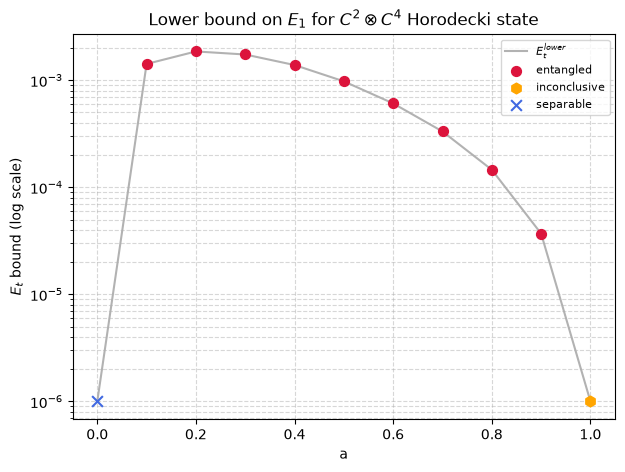

In [5]:
horodecki_res = get_SDP_bounds(
    m=2,
    n=4,
    generator=horodecki,
    label="C2C4_horodecki",
    param_range=(0.00, 1.0, 0.1),
)
plot_Etl_bounds(horodecki_res, "Lower bound on $E_1$ for $C^2 \\otimes C^4$ Horodecki state", xlabel="a", param_range=(0.00, 1.0, 0.1))

[get_SDP_bounds] 11/11 point(s) already in sdp_results/C2C4_horodecki_m2_k3.jsonl, computing the remaining 0


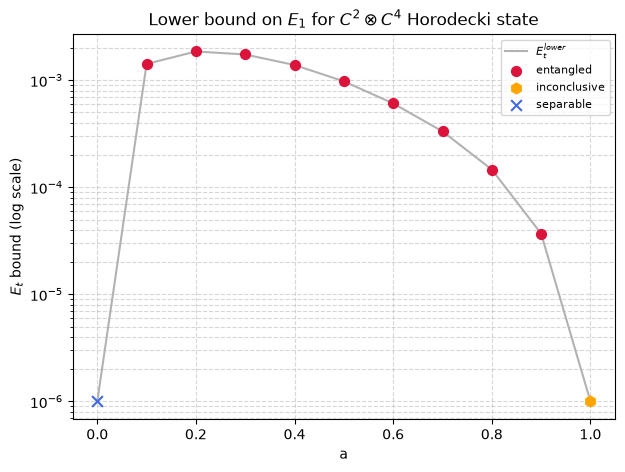

In [6]:
horodecki_res2 = get_SDP_bounds(m=2, n=4, generator=horodecki, label="C2C4_horodecki", param_range=(0.00, 1.0, 0.1), k=3)
plot_Etl_bounds(horodecki_res2, "Lower bound on $E_1$ for $C^2 \\otimes C^4$ Horodecki state", xlabel="a", param_range=(0.00, 1.0, 0.1))

[get_SDP_bounds] 11/11 point(s) already in sdp_results/chessboard-crosshatch_m3_k2.jsonl, computing the remaining 0


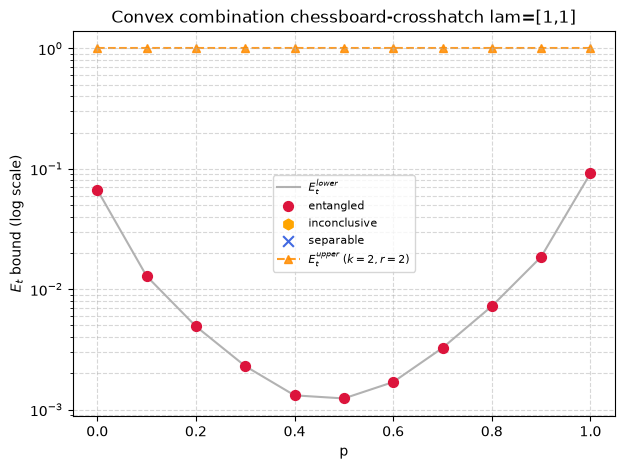

[get_SDP_bounds] computing 11 point(s) into sdp_results/chessboard-crosshatch_m3_k3.jsonl


chessboard-crosshatch:   0%|          | 0/11 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from bound_entangled.c3_otimes_c3 import chessboard_extremal_PPT, cross_hatch, tiles_upb, pyramid_upb, horodecki, steering_state
from bound_entangled.cd_otimes_cd import yu_oh

rangeit = (0.0, 1.0, 0.1)

states = [
    ("chessboard", chessboard_extremal_PPT()),
    ("crosshatch", cross_hatch()),
    ("tiles upb", tiles_upb()),
    ("pyramid upb", pyramid_upb()),
    ("horodecki.2", horodecki(0.2)),
    # ("steering.4.4", steering_state(0.4, 0.4)),
    # ("yu_oh", yu_oh(full_dim=3, x=0.4, y=0.4)),
]

for i in range(len(states)):
    for j in range(i + 1, len(states)):
        state_name1, state1 = states[i]
        state_name2, state2 = states[j]
        gen = convex_combination_generator(state1, state2)
        res = get_SDP_bounds(
            m=3,
            n=3,
            generator=gen,
            label=f"{state_name1}-{state_name2}",
            param_range=rangeit,
        )
        plot_Etl_bounds(res, f"Convex combination {state_name1}-{state_name2} lam=[1,1]", param_range=rangeit)

        res_k3 = get_SDP_bounds(
            m=3,
            n=3,
            generator=gen,
            label=f"{state_name1}-{state_name2}_k3",
            param_range=rangeit,
            k=3,
        )
        plot_Etl_bounds(res_k3, f"Convex combination {state_name1}-{state_name2} lam=[2,1]", param_range=rangeit)